In [2]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.9 MB/s eta 0:00:00


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="#########")
project = rf.workspace("joseph-nelson").project("chess-pieces-new")
version = project.version(25)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chess-Pieces-25 in yolov11:: 100%|██████████| 1398/1398 [00:00<00:00, 6413.54it/s]


In [7]:
!cat /content/Chess-Pieces-25/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

roboflow:
  workspace: joseph-nelson
  project: chess-pieces-new
  version: 25
  license: Public Domain
  url: https://universe.roboflow.com/joseph-nelson/chess-pieces-new/dataset/25

In [8]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
results = model.train(
    data="/content/Chess-Pieces-25/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Chess-Pieces-25/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [10]:
metrics = model.val()

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 789.1±252.7 MB/s, size: 23.9 KB)
val: Scanning /content/Chess-Pieces-25/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 13.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.2s
                   all         58        386      0.955      0.958      0.977      0.792
          black-bishop         13         22          1      0.892      0.957      0.715
            black-king         29         29      0.987      0.966      0.985      0.827
          black-knight         26         30      0.971          1      0.995      0.844
            black-pawn         25         77      0.982          1      0.995      0.798
           black-queen         11         11

In [11]:
results = model.predict(
    source="/content/Chess-Pieces-25/test/images",
    save=True,
    conf=0.25
)


image 1/29 /content/Chess-Pieces-25/test/images/0b47311f426ff926578c9d738d683e76_jpg.rf.40183eae584a653181bbd795ba3c353f.jpg: 640x640 1 white-bishop, 1 white-queen, 7.9ms
image 2/29 /content/Chess-Pieces-25/test/images/1c0060ef868bdc326ce5e6389cb6732f_jpg.rf.f02cd668d26a53d9bf001497992b3657.jpg: 640x640 1 white-knight, 1 white-rook, 8.2ms
image 3/29 /content/Chess-Pieces-25/test/images/2f6fb003bb89cd401322a535acb42f65_jpg.rf.66c0a46773a9cd583fb96c3df41a9e0c.jpg: 640x640 2 black-bishops, 1 black-king, 2 black-knights, 9 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 8 white-pawns, 1 white-queen, 2 white-rooks, 7.9ms
image 4/29 /content/Chess-Pieces-25/test/images/410993714e325a1de3e394ffe860df3a_jpg.rf.657c49ca295ef54da23469189070a075.jpg: 640x640 2 black-bishops, 1 black-king, 2 black-knights, 6 black-pawns, 1 black-queen, 2 black-rooks, 3 white-bishops, 1 white-king, 2 white-knights, 6 white-pawns, 1 white-queen, 1 white-rook, 7.9ms
image 5

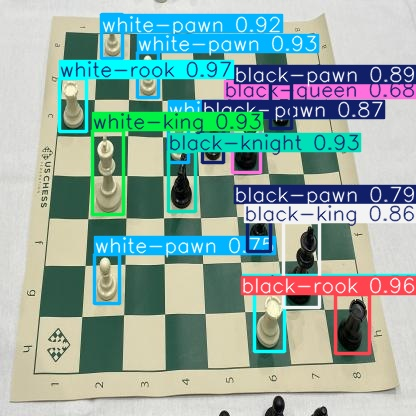

In [12]:
from PIL import Image
import os

pred_folder = "/content/runs/detect/predict"

images = os.listdir(pred_folder)

Image.open(os.path.join(pred_folder, images[0]))